In [52]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from factor_diffusion_train import FactorDenoiser
from factor_diffusion_levy import levy_noise_schedule
from factor_diffusion_sample import generate
import matplotlib.patches as mpatches
import yaml

-  max is increasing via sample size and it is not stable in market factor
- N = 4096 other fatcor are stable

In [53]:
# train / sampling config
with open("cfg.yaml") as f:
    _all_cfg = yaml.safe_load(f)
    _tcfg    = _all_cfg["train"]
    _scfg    = _all_cfg["sample"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_TIMESTEPS = _tcfg["num_timesteps"]
LEVY_ALPHA    = _tcfg["levy_alpha"]
PREFIX        = _tcfg["prefix"]
BATCH_SIZE    = _tcfg["batch_size"]
FACTOR_NAMES  = _tcfg["factor_names"]
NUM_GENERATE  = _scfg["num_generate"]
FACTOR_DIM    = len(_tcfg["factor_names"])
CHECKPOINT    = f"{PREFIX}/checkpoints/factor_DLPM_ep0200.pt"
OUT_PATH      = f"{PREFIX}/samples/factor_{NUM_GENERATE}.npy"

In [54]:
# util functions
def _to_norm(scaler, value, idx):
    dummy = np.zeros((1, FACTOR_DIM))
    dummy[0, idx] = value
    return float(scaler.transform(dummy)[0, idx])

def make_cond_fn(interval, scaler, feature_idx=0):
    thl, thr = interval
    qmin_norm = _to_norm(scaler, thl, feature_idx)
    qmax_norm = _to_norm(scaler, thr, feature_idx)

    def cond_fn(x0_hat):
        return (torch.relu(x0_hat[:, feature_idx] - qmax_norm) +
                torch.relu(qmin_norm - x0_hat[:, feature_idx]))
    cond_fn.label = f"{FACTOR_NAMES[feature_idx]} between [{thl:.4f}, {thr:.4f}]"
    return cond_fn

In [55]:
# load achievements
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model = FactorDenoiser(**ckpt["model_kwargs"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
gammas, bargammas, sigmas, barsigmas = levy_noise_schedule(LEVY_ALPHA, NUM_TIMESTEPS)
scaler = ckpt["scaler"]
args   = (model, gammas, bargammas, sigmas, barsigmas, LEVY_ALPHA, scaler)

In [56]:
"""
Ns = [128, 256, 512, 1028, 2048, 4096, 10000]
uncons = [generate(*args, num_samples=N) for N in Ns]
maxns = [np.max(uncon[0], axis=0) for uncon in uncons]
maxns
q3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]
qmins = [uncon[0].min(axis=0) for uncon in uncons]
fidx  = FACTOR_NAMES.index("momentum")
conds = []
for q3, qmin in zip(q3s, qmins):
    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)
    conds.append(cond)

cons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)
         for c, n in zip(conds, Ns)]
maxns = [np.max(con[0], axis) for con in cons]
maxns
"""

'\nNs = [128, 256, 512, 1028, 2048, 4096, 10000]\nuncons = [generate(*args, num_samples=N) for N in Ns]\nmaxns = [np.max(uncon[0], axis=0) for uncon in uncons]\nmaxns\nq3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]\nqmins = [uncon[0].min(axis=0) for uncon in uncons]\nfidx  = FACTOR_NAMES.index("momentum")\nconds = []\nfor q3, qmin in zip(q3s, qmins):\n    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)\n    conds.append(cond)\n\ncons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)\n         for c, n in zip(conds, Ns)]\nmaxns = [np.max(con[0], axis) for con in cons]\nmaxns\n'

In [57]:
# unconditional sample and conditional config
GUIDANCE_S = 5 # guidance scale
N = 4096 # sample number
uncon, _, _  = generate(*args, num_samples=N)

### Violin Plot - Momentum

In [58]:
q3   = np.percentile(uncon, 3,  axis=0)
qmin = uncon.min(axis=0)
fidx = FACTOR_NAMES.index("momentum")
lower001_fn  = make_cond_fn((qmin[fidx], q3[fidx]),  scaler, fidx)
lower001, _, _  = generate(*args, cond_fn=lower001_fn,  guidance_scale=GUIDANCE_S, num_samples=N)
print(lower001_fn.label)

momentum between [-0.0232, -0.0045]


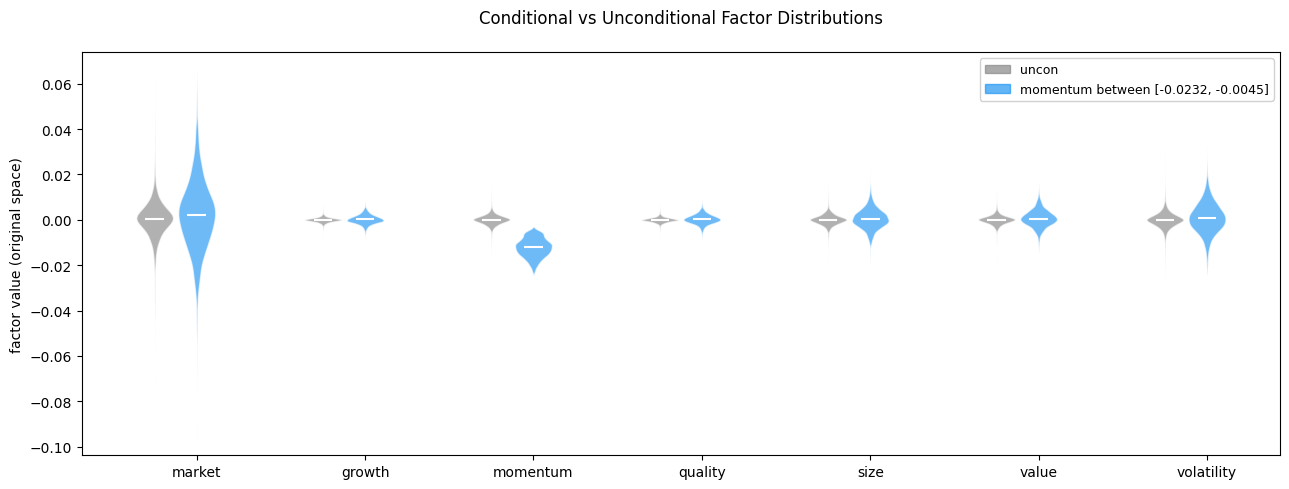

In [59]:
COLORS = {
    "uncon":  "#888888",
    "con":  "#2196F3",
}


datasets = [
    ("uncon",              uncon,     COLORS["uncon"]),
    (lower001_fn.label,    lower001,  COLORS["con"]),
]

x_center = np.arange(FACTOR_DIM)
offsets  = [-0.25, 0.0, 0.25]

fig, ax = plt.subplots(figsize=(13, 5))

for offset, (label, data, color) in zip(offsets, datasets):
    parts = ax.violinplot(
        [data[:, i] for i in range(FACTOR_DIM)],
        positions=x_center + offset,
        widths=0.22,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor("white")
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

ax.set_xticks(x_center)
ax.set_xticklabels(FACTOR_NAMES, fontsize=10)
ax.set_ylabel("factor value (original space)")
ax.set_title(
    f"Conditional vs Unconditional Factor Distributions\n"
)

handles = [mpatches.Patch(color=c, alpha=0.7, label=l) for l, _, c in datasets]
ax.legend(handles=handles, fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()


### Correlation Heatmaps - Unconditional vs Conditional

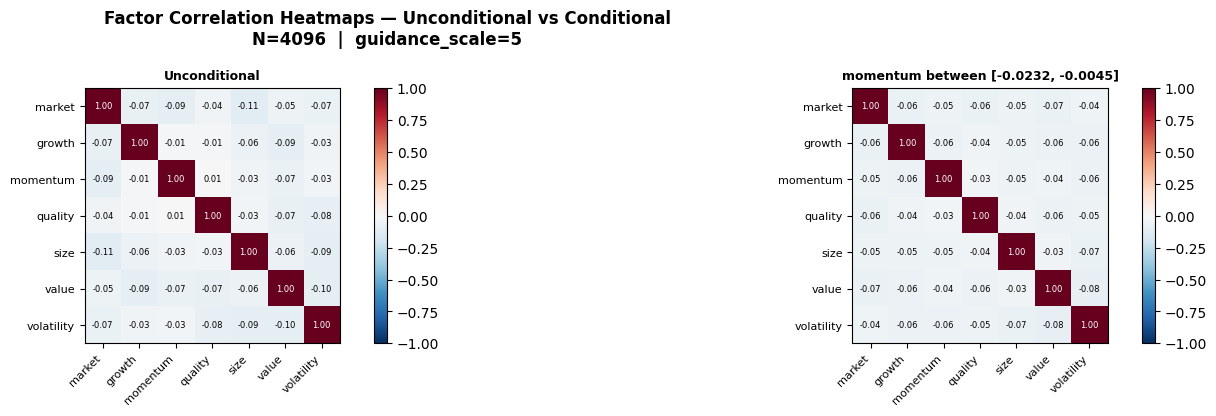

In [60]:
from matplotlib.colors import TwoSlopeNorm

def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

corr_uncon = corr_mat(uncon)
corr_low   = corr_mat(lower001)
corr_diff  = corr_low - corr_uncon   # change under low-momentum stress

panels = [
    ("Unconditional",          corr_uncon, TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),  "RdBu_r"),
    (lower001_fn.label,        corr_low,   TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),  "RdBu_r"),
]

fig, axes = plt.subplots(1, 2, figsize=(17, 4.2))

for ax, (name, corr, norm, cmap) in zip(axes, panels):
    im = ax.imshow(corr, cmap=cmap, norm=norm)
    ax.set_xticks(range(FACTOR_DIM))
    ax.set_yticks(range(FACTOR_DIM))
    ax.set_xticklabels(FACTOR_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(FACTOR_NAMES, fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=9)
    for ii in range(FACTOR_DIM):
        for jj in range(FACTOR_DIM):
            ax.text(jj, ii, f'{corr[ii, jj]:.2f}',
                    ha='center', va='center', fontsize=6,
                    color='white' if abs(corr[ii, jj]) > 0.5 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f'Factor Correlation Heatmaps — Unconditional vs Conditional\n'
    f'N={N}  |  guidance_scale={GUIDANCE_S}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()
